In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore') #불필요한 경고메시지 출력하지 않도록 설정

In [2]:
!pwd

/home/govlept1004/jupyter_home


In [17]:
## DataFrame 생성 ##

src = './data/tfrecord_cat_dog/'
df = pd.DataFrame(os.listdir(src),
                 columns=['filename'])  #폴더에 있는 파일명을 리스트(이름명)해주는 코드
df['label'] = ~df['filename'].str.contains('cat')  #문자열에 해당 문자가 포함되어있니? 답은 논리값으로 떨어짐(0,1)
df = df.astype({'label':'int'}) #논리값을 숫자로 변환
df['filename'] = df['filename'].map(lambda x:src + x)
df

,filename,label
0,./data/tfrecord_cat_dog/cat.620.jpg,0
1,./data/tfrecord_cat_dog/cat.488.jpg,0
2,./data/tfrecord_cat_dog/dog.740.jpg,1
3,./data/tfrecord_cat_dog/cat.62.jpg,0
4,./data/tfrecord_cat_dog/cat.343.jpg,0
...,...,...
3996,./data/tfrecord_cat_dog/dog.1427.jpg,1
3997,./data/tfrecord_cat_dog/cat.519.jpg,0
3998,./data/tfrecord_cat_dog/cat.643.jpg,0
3999,./data/tfrecord_cat_dog/cat.705.jpg,0


In [21]:
## 데이터분리 및 TFRecord 생성 ##
x_data_train, x_data_valid, t_data_train, t_data_valid = train_test_split(df['filename'],
                                                                         df['label'],
                                                                         test_size=0.2,
                                                                         stratify=df['label'])

In [32]:
def to_tfrecords(filename_list, label_list, tfrecords_name):
    # filename_list : 이미지 파일명을 가지고 있는 list
    # label_list : 이미지 파일 label을 가지고 있는 list
    # tfrecords_name : TFRecords 이름
    print('파일 생성 시작')
    tf_filename = os.path.join(tfrecords_name + '.tfrecords')
    with tf.io.TFRecordWriter(path=tf_filename) as writer:  #즉, path = ./cat_dog_train.tfrecords
        for filename_, label_ in tqdm(zip(filename_list, label_list), # zip은 별도의 데이터를 합쳐서 튜플로 만들어주는 함수
                                     total=len(filename_list),
                                     position=0,
                                     leave=True):
            _binary_image = tf.io.read_file(filename_).numpy()
            feature = {
                'image_raw': tf.train.Feature(bytes_list = tf.train.BytesList(
                    value=[_binary_image]
                )),
                'label': tf.train.Feature(int64_list = tf.train.Int64List(
                    value=[label_]
                ))
            }
            features = tf.train.Features(feature=feature)
            example = tf.train.Example(features=features)

            writer.write(example.SerializeToString())
        

In [35]:
# 실제 존재하는 이미지 경로만 필터링
x_data_valid = [f for f in x_data_valid if os.path.isfile(f)]
t_data_valid = [label for f, label in zip(x_data_valid, t_data_valid) if os.path.isfile(f)]

# 동일하게 학습 데이터도 필터링
x_data_train = [f for f in x_data_train if os.path.isfile(f)]
t_data_train = [label for f, label in zip(x_data_train, t_data_train) if os.path.isfile(f)]

to_tfrecords(x_data_train, t_data_train, './cat_dog_train')
to_tfrecords(x_data_valid, t_data_valid, './cat_dog_valid')
# 가지고 있는 file 데이터(이미지)를 TFRecord로 변환
# 이 TFRecord를 읽어들여서 tf.data.Dataset으로 만들고
# 이 Dataset을 모델의 입력으로 넣어서 최적의 입력형태를 만들어서 사용
# TFRecord는 파일의 내용을 변형시키지 않고 저장하는게 일반적
# 실제 학습에 필요한 형태로 변환시키는 작업은 Dataset에서 실행!


파일 생성 시작


  0%|          | 0/3200 [00:00<?, ?it/s]

파일 생성 시작


  0%|          | 0/800 [00:00<?, ?it/s]

In [48]:
# TFRecord에 이미지가 잘 저장되었는지 확인해보아요
# tf.data.Dataset을 이용해서 처리해야 해요

train_tfrecored_path = './cat_dog_train.tfrecords'

BUFFER_SIZE = 1000  #shuffle때문에 설정
BATCH_SIZE = 32  #배치크기
IMAGE_SIZE = 150  #이미지크기

In [55]:
# TFRecord를 읽으려면 feature description을 작성해야 해요
feature_description = {
    'image_raw' : tf.io.FixedLenFeature([], tf.string),
    'label' : tf.io.FixedLenFeature([], tf.int64)
}
# TFRecord 안에 있는 각각의 Example 객체를 읽어들여서 복원
def _parse_image_function(proto):
    return tf.io.parse_single_example(proto, feature_description)


# 복원한걸 원하는 거로 변환하는 함수
def get_img_tensor(target_record):
    img = target_record['image_raw']
    label = target_record['label']
    img = tf.image.decode_jpeg(img, channels=3)
    return img, label

def image_preprocessing(img, label):
    result_image = img / 255
    result_image = tf.image.resize(result_image, 
                                  (IMAGE_SIZE,IMAGE_SIZE),
                                  antialias=False)
    return result_image, label

In [56]:
# tf.data.Dataset을 생성해야 해요

dataset = tf.data.TFRecordDataset(train_tfrecored_path)

dataset = dataset.map(_parse_image_function,
                     num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.map(get_img_tensor,
                     num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.map(image_preprocessing,
                     num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.cache() # 속도 증가
dataset = dataset.shuffle(BUFFER_SIZE) # 학습의 효율을 높이기 위해서
dataset = dataset.batch(BATCH_SIZE) # 속도 증가
dataset = dataset.prefetch(tf.data.AUTOTUNE) # 속도 증가

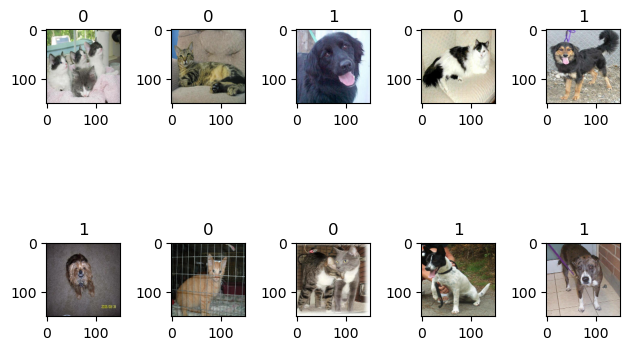

In [58]:
# 그림 그리기
fig = plt.figure()
axes = []

for i in range(10):
    axes.append(fig.add_subplot(2,5,i+1))

for batch_image, batch_label in dataset:
    for i in range(10):
        image_raw = batch_image[i]
        image_label = batch_label[i].numpy()
        axes[i].imshow(image_raw)
        axes[i].set_title(image_label)

    break
plt.tight_layout()
plt.show()

In [59]:
# 이렇게 만들어진 TFRecord를 이용해서 학습에 사용해 볼꺼에요
# 일단 TFRecord를 tf.data.Dataset을 이용해서 사용해야 해요
# 먼저 Dataset만 생성해 놓으면 모델 생성과 모델 설정 및 학습은 우리가 했던대로 진행!

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.layers import Input, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
# Mixed Precision Policy
from tensorflow.keras import mixed_precision #하드웨어가 지원해야 해요! 
mixed_precision.set_global_policy('mixed_float16')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU, compute capability 8.6


In [62]:
tfrecord_train_file = './cat_dog_train.tfrecords'
tfrecord_valid_file = './cat_dog_valid.tfrecords'

# TFRecord를 읽으려면 feature description을 작성해야 해요
feature_description = {
    'image_raw' : tf.io.FixedLenFeature([], tf.string),
    'label' : tf.io.FixedLenFeature([], tf.int64)
}
# TFRecord 안에 있는 각각의 Example 객체를 읽어들여서 복원
def _parse_image_function(proto):
    return tf.io.parse_single_example(proto, feature_description)
    
# 복원한걸 원하는 거로 변환하는 함수
def get_img_tensor(target_record):
    img = target_record['image_raw']
    label = target_record['label']
    img = tf.image.decode_jpeg(img, channels=3)
    return img, label

def image_preprocessing(img, label):
    result_image = img / 255
    result_image = tf.image.resize(result_image, 
                                  (IMAGE_SIZE,IMAGE_SIZE),
                                  antialias=False)
    return result_image, label

## TFRecord에서 데이터를 가져와서 처리하는 함수들을 작성했으니
# 이제 Dataset을 생성해 보아요

def make_dataset(tfrecords_path, is_train):
    dataset = tf.data.TFRecordDataset(tfrecords_path)
    dataset = dataset.map(_parse_image_function,
                         num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(get_img_tensor,
                         num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(image_preprocessing,
                         num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.cache() 
    if is_train : 
        dataset = dataset.shuffle(BUFFER_SIZE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

train_ds = make_dataset(tfrecord_train_file, True)
valid_ds = make_dataset(tfrecord_valid_file, False)

In [64]:
# model 구성
# Functional APT를 이용해서 모델을 구현
# Input Layer가 있어야 해요

input_layer = Input(shape=(150,150,3),
                   name='inputlayer')
# Pretrained Network
pretrained_network = VGG16(weights='imagenet',
                           include_top=False,
                           input_shape=(150,150,3),
                           input_tensor=input_layer)

# Pretrained Network 동결
# pretrained_network.trainable = False
for layer in pretrained_network.layers:
    layer.trainable = False

x = pretrained_network.output
x = GlobalAveragePooling2D()(x)
x = Dense(units=256)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(rate=0.3)(x)
x = Dense(units=1,
         activation='sigmoid',
         dtype='float32')(x)

model = Model(inputs=input_layer,
              outputs=x)
cp_callback = ModelCheckpoint(
    filepath='./cat_dog_small_tfrecord.weights.h5',
    save_best_only=True,
    save_weights_only=True,
    monitor='val_loss',
    verbose=1
)

es_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1    
)

model.compile(optimizer=Adam(learning_rate=1e-4),
             loss='binary_crossentropy',
             metrics=['accuracy'])

# 1차 학습
model.fit(train_ds,
         epochs=20,
         validation_data=valid_ds,
         callbacks=[cp_callback,es_callback],
         verbose=1)

Epoch 1/20
    100/Unknown - 5s 26ms/step - loss: 0.5574 - accuracy: 0.7053
Epoch 1: val_loss improved from inf to 0.68664, saving model to ./cat_dog_small_tfrecord.weights.h5
100/100 [==============================] - 6s 35ms/step - loss: 0.5574 - accuracy: 0.7053 - val_loss: 0.6866 - val_accuracy: 0.5938
Epoch 2/20
100/100 [==============================] - ETA: 0s - loss: 0.3826 - accuracy: 0.8269
Epoch 2: val_loss did not improve from 0.68664
100/100 [==============================] - 3s 29ms/step - loss: 0.3826 - accuracy: 0.8269 - val_loss: 0.7310 - val_accuracy: 0.6037
Epoch 3/20
100/100 [==============================] - ETA: 0s - loss: 0.3336 - accuracy: 0.8556
Epoch 3: val_loss did not improve from 0.68664
100/100 [==============================] - 3s 28ms/step - loss: 0.3336 - accuracy: 0.8556 - val_loss: 0.8374 - val_accuracy: 0.5975
Epoch 4/20
100/100 [==============================] - ETA: 0s - loss: 0.3071 - accuracy: 0.8675
Epoch 4: val_loss did not improve from 0.68664

In [66]:
pretrained_network.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputlayer (InputLayer)     [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [68]:
# 이렇게 1차 학습이 완료되면
# 몇몇개의 레이어의 동결을 풀어서 파인튜닝을 진행

for layer in pretrained_network.layers:
    if layer.name in ['block5_conv1','block5_conv2','block5_conv3']:
        layer.trainable = True
    else:
        layer.trainable = False

# 반드시 compile을 다시 진행해야해요! 일반적으로 learning rate은 값을 줄여요
model.compile(optimizer=Adam(learning_rate=1e-5),
             loss='binary_crossentropy',
             metrics=['accuracy'])

# 2차 학습
model.fit(train_ds,
         epochs=20,
         validation_data=valid_ds,
         callbacks=[cp_callback,es_callback],
         verbose=1)
    

Epoch 1/20
     99/Unknown - 5s 28ms/step - loss: 0.3317 - accuracy: 0.8532
Epoch 1: val_loss did not improve from 0.68664
100/100 [==============================] - 6s 35ms/step - loss: 0.3323 - accuracy: 0.8528 - val_loss: 0.8530 - val_accuracy: 0.6112
Epoch 2/20
 99/100 [============================>.] - ETA: 0s - loss: 0.2177 - accuracy: 0.9122
Epoch 2: val_loss did not improve from 0.68664
100/100 [==============================] - 3s 33ms/step - loss: 0.2168 - accuracy: 0.9128 - val_loss: 1.0810 - val_accuracy: 0.6112
Epoch 3/20
 99/100 [============================>.] - ETA: 0s - loss: 0.1733 - accuracy: 0.9369
Epoch 3: val_loss did not improve from 0.68664
100/100 [==============================] - 3s 33ms/step - loss: 0.1728 - accuracy: 0.9372 - val_loss: 1.2693 - val_accuracy: 0.6150
Epoch 4/20
 99/100 [============================>.] - ETA: 0s - loss: 0.1283 - accuracy: 0.9586
Epoch 4: val_loss did not improve from 0.68664
100/100 [==============================] - 3s 33ms/s